In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame({
    "상품명": ["A", "B", "C", "D", "E", "F", "G"],
    "가격": [12000, 15000, 13000, 14000, 16000, 15500, 500000]
})

In [6]:
Q1 = df["가격"].quantile(0.25)
Q3 = df["가격"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"하한선: {lower_bound}, 상한선: {upper_bound}")

outliers = df[(df["가격"] < lower_bound) | (df["가격"] > upper_bound)]
print(outliers)

df_clean = df[(df["가격"] >= lower_bound) & (df["가격"] <= upper_bound)]

df["가격_보정"] = df["가격"].clip(lower=lower_bound, upper=upper_bound)
df

하한선: 10125.0, 상한선: 19125.0
  상품명      가격  가격_보정
6   G  500000  19125


,상품명,가격,가격_보정
0,A,12000,12000
1,B,15000,15000
2,C,13000,13000
3,D,14000,14000
4,E,16000,16000
5,F,15500,15500
6,G,500000,19125


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
rng = np.random.default_rng(42)

prices = rng.normal(loc=50_000, scale=8_000, size=200).round(-2)

prices = np.append(prices, [180_000, 200_000, 250_000])

df = pd.DataFrame({
    "가격": prices,
    "카테고리": rng.choice(["식품", "의류", "가전"], size=len(prices))
})

In [11]:
df["z_score"] = (df["가격"] - df["가격"].mean()) / df["가격"].std()

df_clean_z = df[df["z_score"].abs() < 3].copy()

print("제거 전 행 개수:", len(df))
print("제거 후 행 개수", len(df_clean_z))
print("제거된 행 개수:", len(df) - len(df_clean_z))
print("제거 비율: {:.2%}".format((len(df) - len(df_clean_z)) / len(df)))

removed = df.loc[~df.index.isin(df_clean_z.index)]
print(removed)

df_clean_z = df_clean_z.reset_index(drop=True)

compare = pd.DataFrame({
    "제거 전": df["가격"].describe(),
    "제거 후": df_clean_z["가격"].describe()
})
print(compare.round(1))

제거 전 행 개수: 203
제거 후 행 개수 200
제거된 행 개수: 3
제거 비율: 1.48%
           가격 카테고리   z_score
200  180000.0   가전  6.112708
201  200000.0   가전  7.068739
202  250000.0   가전  9.458815
           제거 전     제거 후
count     203.0    200.0
mean    52123.2  49755.0
std     20919.8   7055.5
min     32900.0  32900.0
25%     44850.0  44775.0
50%     49700.0  49600.0
75%     54800.0  54300.0
max    250000.0  73300.0


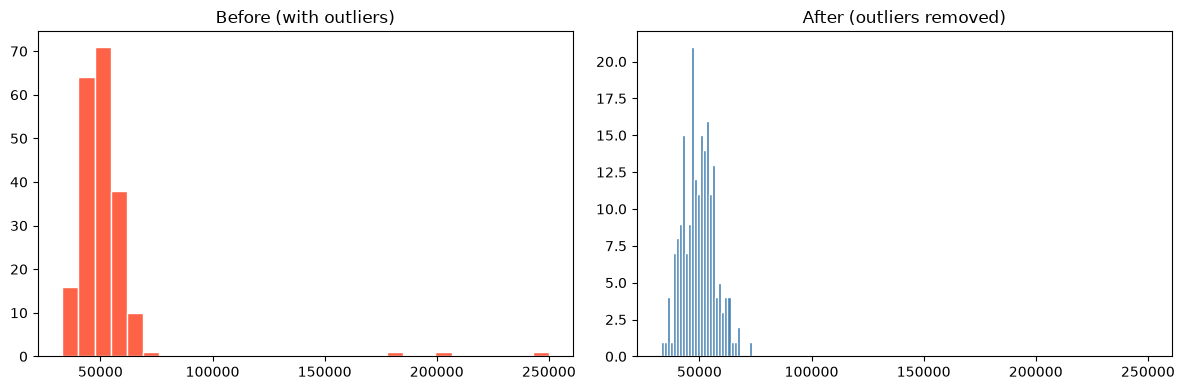

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].hist(df["가격"], bins=30, color="tomato", edgecolor="white")
axes[0].set_title("Before (with outliers)")

axes[1].hist(df_clean_z["가격"], bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("After (outliers removed)")

plt.tight_layout()
plt.show()

In [13]:
summary = df_clean_z.groupby("카테고리")["가격"].agg(["mean", "median", "count"])
print(summary.round(0))

df_clean_z["가격대"] = pd.cut(
    df_clean_z["가격"],
    bins=[0, 40_000, 60_000, np.inf],
    labels=["저가", "중가", "고가"]
)
print(df_clean_z["가격대"].value_counts())

         mean   median  count
카테고리                         
가전    50049.0  49900.0     71
식품    48635.0  48150.0     72
의류    50804.0  50100.0     57
가격대
중가    168
저가     16
고가     16
Name: count, dtype: int64


In [14]:
df_clean_z.to_csv("가격_정제데이터.csv", index=False, encoding="utf-8-sig")